# Visualising the Central Limit Theorem with a Casino's Roulette

Through this, we'll see how the casino always ends up gaining money even if the game we play is not rigged and is completely fair. We'll simulate a simple game where we pick the colour (Red, Black or Green) in which the ball will end up. You pay \$1 initially and then place your guess. If you win, you'll earn 1 additional dollar, and if you lose, you'll lose the initial amount you placed.

We'll simulate this case 1000 times and then finally verify the output against the theoretical values.

**Why this is the Central Limit Theorem in action:** each round is an independent $\pm 1$ outcome, so a player's final bankroll is a *sum* of many independent random variables. The CLT says such sums tend towards a normal distribution, which is exactly what we'll watch emerge below.

We'll import the libraries necessary for this simulation, along with the helper functions from `roulette.py` (which holds the reusable simulation logic).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import roulette

# A seeded generator keeps the notebook reproducible: re-running gives the same plots.
rng = np.random.default_rng(42)

N_GAMES = 1000      # rounds played by a single player
N_PLAYERS = 1000    # number of players we simulate

We'll simulate the bankroll of a player who has played the game 1000 times. We assume the player picks red and black with a probability of 0.5 each and ignores green, given that the chance the ball lands on green is very low.

Notice that the win probability comes out to $18/38 \approx 0.474$, *not* 0.5; the two green pockets are the house edge.

<>:11: SyntaxWarning: invalid escape sequence '\$'
<>:11: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_592/222479621.py:11: SyntaxWarning: invalid escape sequence '\$'
  plt.ylabel('Bankroll (\$)')


Probability of winning a single round: 0.4737


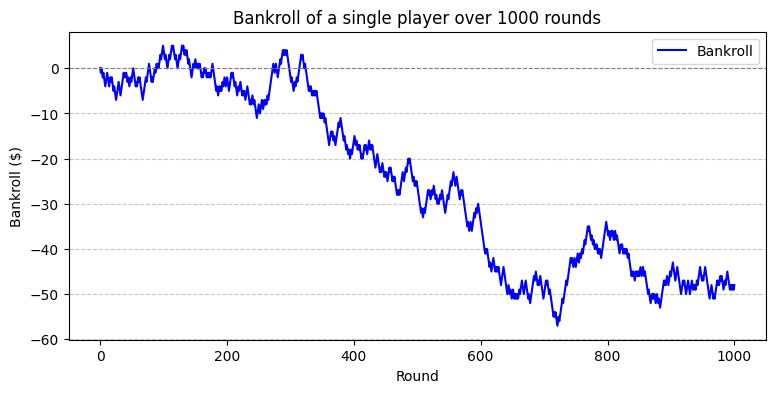

In [2]:
win_prob = roulette.win_probability(p_red=0.5, p_black=0.5, p_green=0.0)
print(f'Probability of winning a single round: {win_prob:.4f}')

bankroll = roulette.simulate_bankroll(N_GAMES, win_prob, rng)

plt.figure(figsize=(9, 4))
plt.plot(bankroll, color='blue', linewidth=1.5, label='Bankroll')
plt.axhline(0, color='grey', linewidth=0.8, linestyle='--')
plt.title('Bankroll of a single player over 1000 rounds')
plt.xlabel('Round')
plt.ylabel('Bankroll (\$)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Now we'll perform the same simulation for 1000 such players, each playing 1000 times, and plot their final bankrolls in a histogram.

<>:6: SyntaxWarning: invalid escape sequence '\$'
<>:6: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_592/1500436210.py:6: SyntaxWarning: invalid escape sequence '\$'
  plt.xlabel('Final bankroll (\$)')


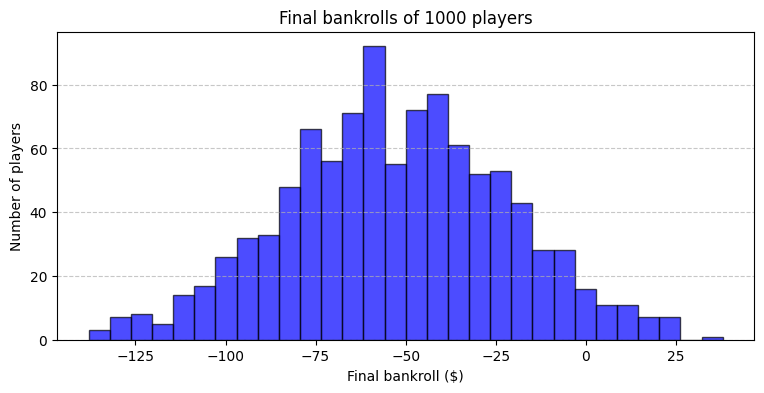

In [3]:
final_bankrolls = roulette.simulate_final_bankrolls(N_PLAYERS, N_GAMES, win_prob, rng)

plt.figure(figsize=(9, 4))
plt.hist(final_bankrolls, bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.title('Final bankrolls of 1000 players')
plt.xlabel('Final bankroll (\$)')
plt.ylabel('Number of players')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The graph generated above looks similar to a Gaussian curve. Now we'll check whether the Gaussian we get from the *theoretical* mean and variance fits the histogram we obtained from the simulation.

The theoretical results for a sum of $n$ independent $\pm 1$ outcomes are:

$$\mu = n\,(2p - 1), \qquad \sigma^2 = n\,\cdot 4p(1 - p)$$

<>:17: SyntaxWarning: invalid escape sequence '\$'
<>:17: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_592/2134850769.py:17: SyntaxWarning: invalid escape sequence '\$'
  plt.xlabel('Final bankroll (\$)')


Theoretical mean: -52.63,  theoretical std: 31.58
Simulated   mean: -52.86,  simulated   std: 30.80


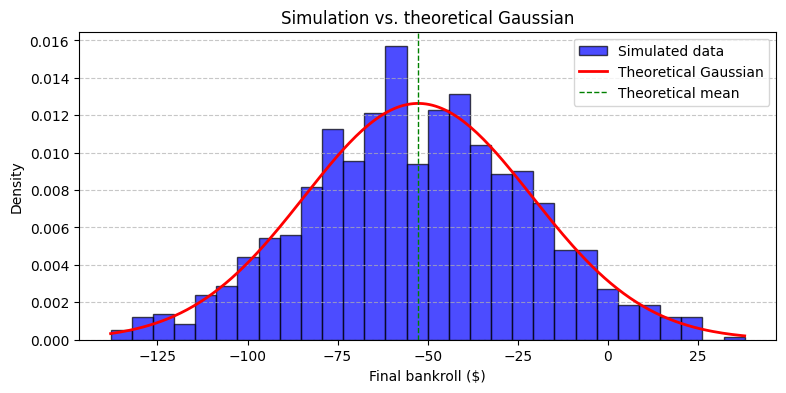

In [4]:
from scipy.stats import norm

mean = roulette.theoretical_mean(N_GAMES, win_prob)
std = roulette.theoretical_std(N_GAMES, win_prob)
print(f'Theoretical mean: {mean:.2f},  theoretical std: {std:.2f}')
print(f'Simulated   mean: {final_bankrolls.mean():.2f},  simulated   std: {final_bankrolls.std():.2f}')

x = np.linspace(final_bankrolls.min(), final_bankrolls.max(), 200)
gauss_curve = norm.pdf(x, loc=mean, scale=std)

plt.figure(figsize=(9, 4))
plt.hist(final_bankrolls, bins=30, color='blue', edgecolor='black', alpha=0.7,
         density=True, label='Simulated data')
plt.plot(x, gauss_curve, color='red', linewidth=2, label='Theoretical Gaussian')
plt.axvline(mean, color='green', linestyle='--', linewidth=1, label='Theoretical mean')
plt.title('Simulation vs. theoretical Gaussian')
plt.xlabel('Final bankroll (\$)')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

By looking at the Gaussian curve overlaid on the histogram, it is pretty clear that the simulation and the theory go hand in hand, and that we could use simulations in places where it's hard to perform the analysis theoretically.

Notice too that the entire distribution sits to the *left* of zero (centred near $\mu = n(2p-1) < 0$). That negative mean is the house edge: averaged over many players, the casino comes out ahead, even though every individual round looked like a fair coin flip.